In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("CUSTOMER ANALYTICS: CLTV, RFM, AND KMEANS CLUSTERING")
print("="*60)


CUSTOMER ANALYTICS: CLTV, RFM, AND KMEANS CLUSTERING


In [ ]:
# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================
print("\n[STEP 1] Loading and exploring data...")

df = pd.read_excel('https://github.com/fenago/datasets/raw/refs/heads/main/Online%20Retail%20(1).xlsx')

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn Info:")
print(df.info())
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nBasic Statistics:")
print(df.describe())


[STEP 1] Loading and exploring data...

Dataset Shape: (541909, 8)

First few rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns

In [ ]:
# ============================================================================
# STEP 2: CLEAN DATA
# ============================================================================
print("\n[STEP 2] Cleaning data...")

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])
# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]
# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]
# Calculate total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"\nClean Dataset Shape: {df.shape}")
print(f"Number of Unique Customers: {df['CustomerID'].nunique()}")
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")



[STEP 2] Cleaning data...

Clean Dataset Shape: (397884, 9)
Number of Unique Customers: 4338
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [ ]:
# ============================================================================
# STEP 3: CALCULATE RFM METRICS
# ============================================================================
print("\n[STEP 3] Calculating RFM metrics...")

# Set snapshot date (day after last transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("\nRFM Summary Statistics:")
print(rfm.describe())

# Create RFM Scores (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Create RFM Segment
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Segment'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Create customer segments
def segment_customer(row):
    if row['RFM_Segment'] >= 9 and row['R_Score'] >= 4:
        return 'Champions'
    elif row['RFM_Segment'] >= 6 and row['R_Score'] >= 3:
        return 'Loyal Customers'
    elif row['F_Score'] >= 3 and row['R_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] >= 4:
        return 'Recent Customers'
    elif row['RFM_Segment'] >= 6 and row['R_Score'] <= 2:
        return 'At Risk'
    elif row['F_Score'] >= 2 and row['R_Score'] <= 2:
        return 'Cant Lose Them'
    elif row['R_Score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

print("\nCustomer Segment Distribution:")
print(rfm['Customer_Segment'].value_counts())


[STEP 3] Calculating RFM metrics...

RFM Summary Statistics:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000

Customer Segment Distribution:
Customer_Segment
Champions          1520
Loyal Customers    1043
At Risk             892
Lost                485
Cant Lose Them      331
Others               67
Name: count, dtype: int64



[STEP 4] Creating RFM distribution visualizations...


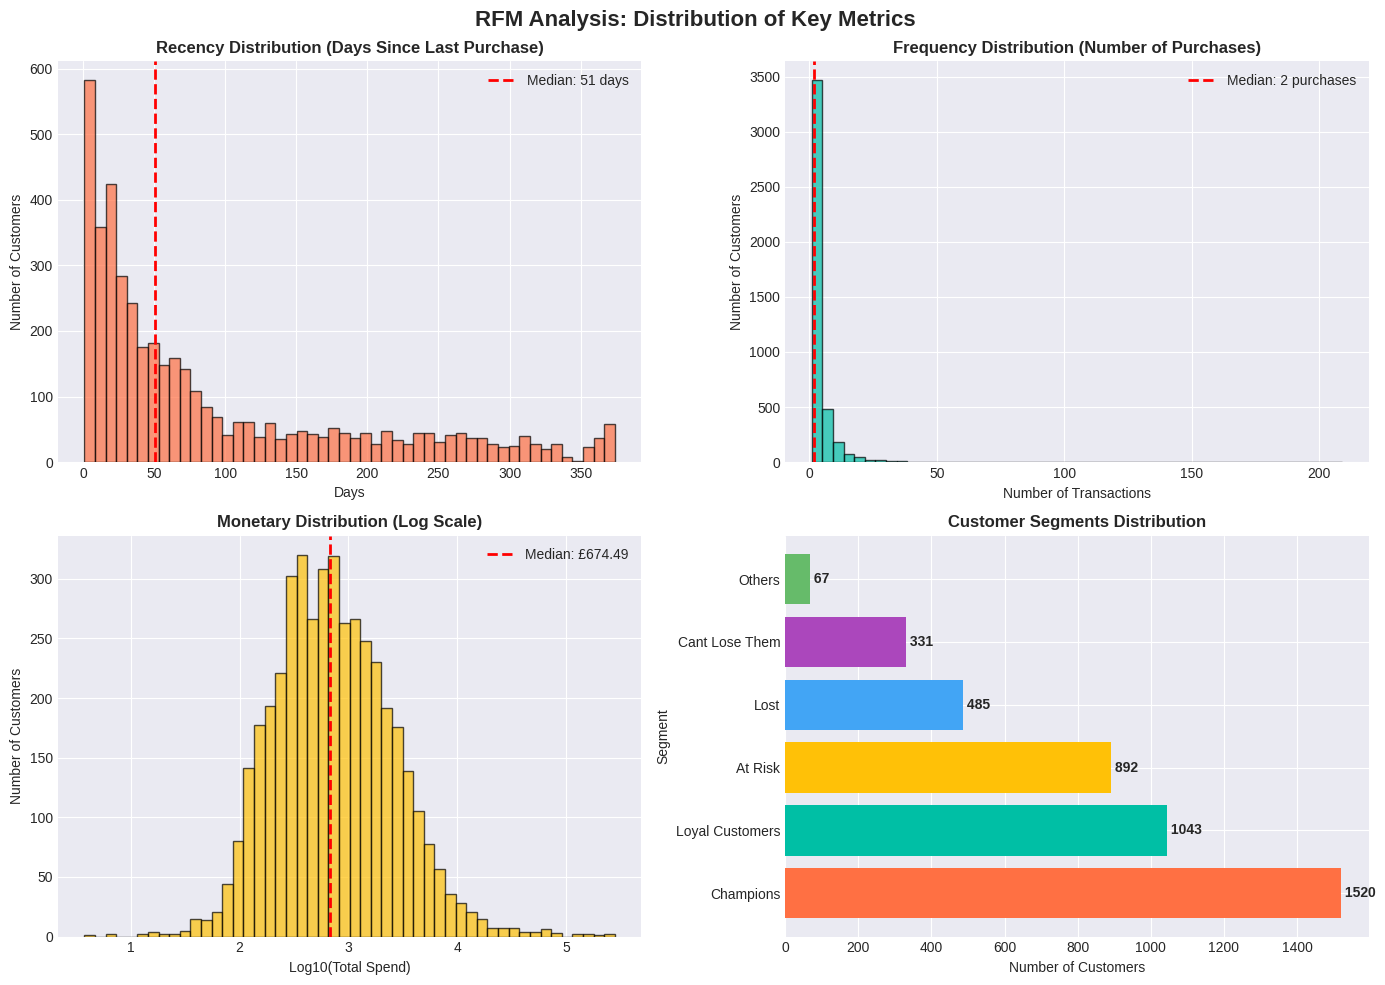

RFM distribution visualization complete!


In [ ]:
# ============================================================================
# STEP 4: VISUALIZE RFM DISTRIBUTIONS
# ============================================================================
print("\n[STEP 4] Creating RFM distribution visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RFM Analysis: Distribution of Key Metrics', fontsize=16, fontweight='bold')

# Recency distribution
axes[0, 0].hist(rfm['Recency'], bins=50, color='#FF7043', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Recency Distribution (Days Since Last Purchase)', fontweight='bold')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].axvline(rfm['Recency'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {rfm["Recency"].median():.0f} days')
axes[0, 0].legend()

# Frequency distribution
axes[0, 1].hist(rfm['Frequency'], bins=50, color='#00BFA5', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Frequency Distribution (Number of Purchases)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Transactions')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].axvline(rfm['Frequency'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {rfm["Frequency"].median():.0f} purchases')
axes[0, 1].legend()

# Monetary distribution (log scale)
axes[1, 0].hist(np.log10(rfm['Monetary']), bins=50, color='#FFC107', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Monetary Distribution (Log Scale)', fontweight='bold')
axes[1, 0].set_xlabel('Log10(Total Spend)')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].axvline(np.log10(rfm['Monetary'].median()), color='red', linestyle='--', linewidth=2, label=f'Median: £{rfm["Monetary"].median():.2f}')
axes[1, 0].legend()

# Customer Segments
segment_counts = rfm['Customer_Segment'].value_counts()
colors_palette = ['#FF7043', '#00BFA5', '#FFC107', '#42A5F5', '#AB47BC', '#66BB6A', '#FFA726', '#EC407A']
axes[1, 1].barh(segment_counts.index, segment_counts.values, color=colors_palette[:len(segment_counts)])
axes[1, 1].set_title('Customer Segments Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Number of Customers')
axes[1, 1].set_ylabel('Segment')

for i, v in enumerate(segment_counts.values):
    axes[1, 1].text(v, i, f' {v}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("RFM distribution visualization complete!")


[STEP 5] Analyzing segments...

Segment Analysis Summary:
                  Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Customer_Segment                                                 
Champions               13.94           8.04       4226.53   1520
At Risk                151.63           2.81       1264.03    892
Loyal Customers         44.39           2.77       1108.48   1043
Lost                   232.66           1.00        255.55    485
Cant Lose Them         248.47           1.12        206.90    331
Others                  53.52           1.00        164.15     67


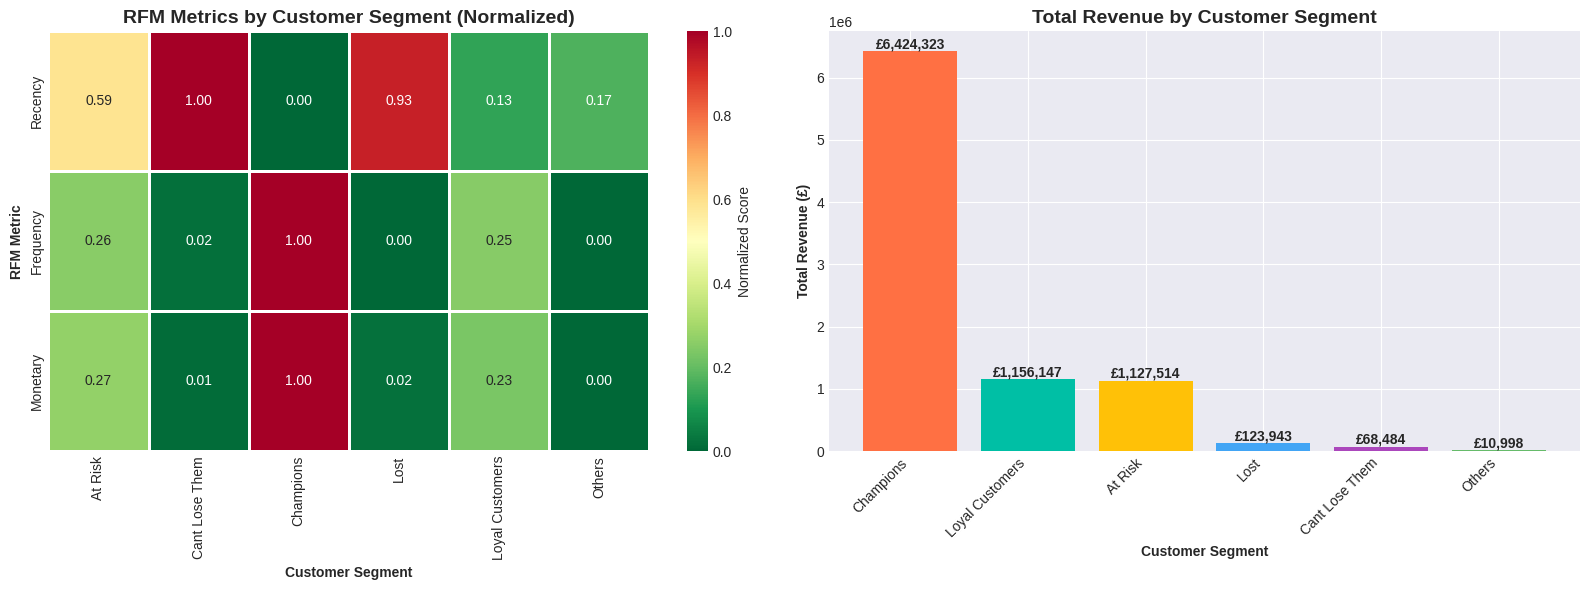

Segment analysis visualization complete!


In [ ]:
# ============================================================================
# STEP 5: SEGMENT ANALYSIS
# ============================================================================
print("\n[STEP 5] Analyzing segments...")

segment_summary = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).round(2)
segment_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Count']
segment_summary = segment_summary.sort_values('Avg_Monetary', ascending=False)

print("\nSegment Analysis Summary:")
print(segment_summary)

# Create heatmap and segment value visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Average metrics by segment
segment_metrics = rfm.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean()
segment_metrics_normalized = (segment_metrics - segment_metrics.min()) / (segment_metrics.max() - segment_metrics.min())

sns.heatmap(segment_metrics_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=1, cbar_kws={'label': 'Normalized Score'}, ax=axes[0])
axes[0].set_title('RFM Metrics by Customer Segment (Normalized)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Customer Segment', fontweight='bold')
axes[0].set_ylabel('RFM Metric', fontweight='bold')

# Segment value contribution
segment_value = rfm.groupby('Customer_Segment')['Monetary'].sum().sort_values(ascending=False)
colors_palette = ['#FF7043', '#00BFA5', '#FFC107', '#42A5F5', '#AB47BC', '#66BB6A', '#FFA726', '#EC407A']
axes[1].bar(range(len(segment_value)), segment_value.values, color=colors_palette[:len(segment_value)])
axes[1].set_xticks(range(len(segment_value)))
axes[1].set_xticklabels(segment_value.index, rotation=45, ha='right')
axes[1].set_title('Total Revenue by Customer Segment', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Customer Segment', fontweight='bold')
axes[1].set_ylabel('Total Revenue (£)', fontweight='bold')

for i, v in enumerate(segment_value.values):
    axes[1].text(i, v, f'£{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Segment analysis visualization complete!")

In [ ]:
# ============================================================================
# STEP 6: CALCULATE CUSTOMER LIFETIME VALUE (CLTV)
# ============================================================================
print("\n[STEP 6] Calculating Customer Lifetime Value...")

cltv_data = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum',
    'InvoiceDate': lambda x: (x.max() - x.min()).days
}).reset_index()

cltv_data.columns = ['CustomerID', 'NumPurchases', 'TotalRevenue', 'CustomerLifespan']

# Calculate CLTV components
cltv_data['AvgOrderValue'] = cltv_data['TotalRevenue'] / cltv_data['NumPurchases']
cltv_data['PurchaseFrequency'] = cltv_data['NumPurchases'] / (cltv_data['CustomerLifespan'] + 1) * 365
cltv_data['CustomerLifespanYears'] = (cltv_data['CustomerLifespan'] + 1) / 365
cltv_data['CLTV'] = cltv_data['AvgOrderValue'] * cltv_data['PurchaseFrequency'] * cltv_data['CustomerLifespanYears']

# Remove extreme outliers for visualization
cltv_data_clean = cltv_data[cltv_data['CLTV'] <= cltv_data['CLTV'].quantile(0.99)]

print("\nCustomer Lifetime Value Summary:")
print(cltv_data_clean['CLTV'].describe())
print(f"\nTotal Customer Lifetime Value: £{cltv_data_clean['CLTV'].sum():,.2f}")
print(f"Average CLTV per Customer: £{cltv_data_clean['CLTV'].mean():,.2f}")
print(f"Median CLTV per Customer: £{cltv_data_clean['CLTV'].median():,.2f}")


[STEP 6] Calculating Customer Lifetime Value...

Customer Lifetime Value Summary:
count     4294.000000
mean      1411.238783
std       2108.837909
min          3.750000
25%        305.867500
50%        663.730000
75%       1612.415000
max      19824.050000
Name: CLTV, dtype: float64

Total Customer Lifetime Value: £6,059,859.33
Average CLTV per Customer: £1,411.24
Median CLTV per Customer: £663.73



[STEP 7] Creating CLTV visualizations...


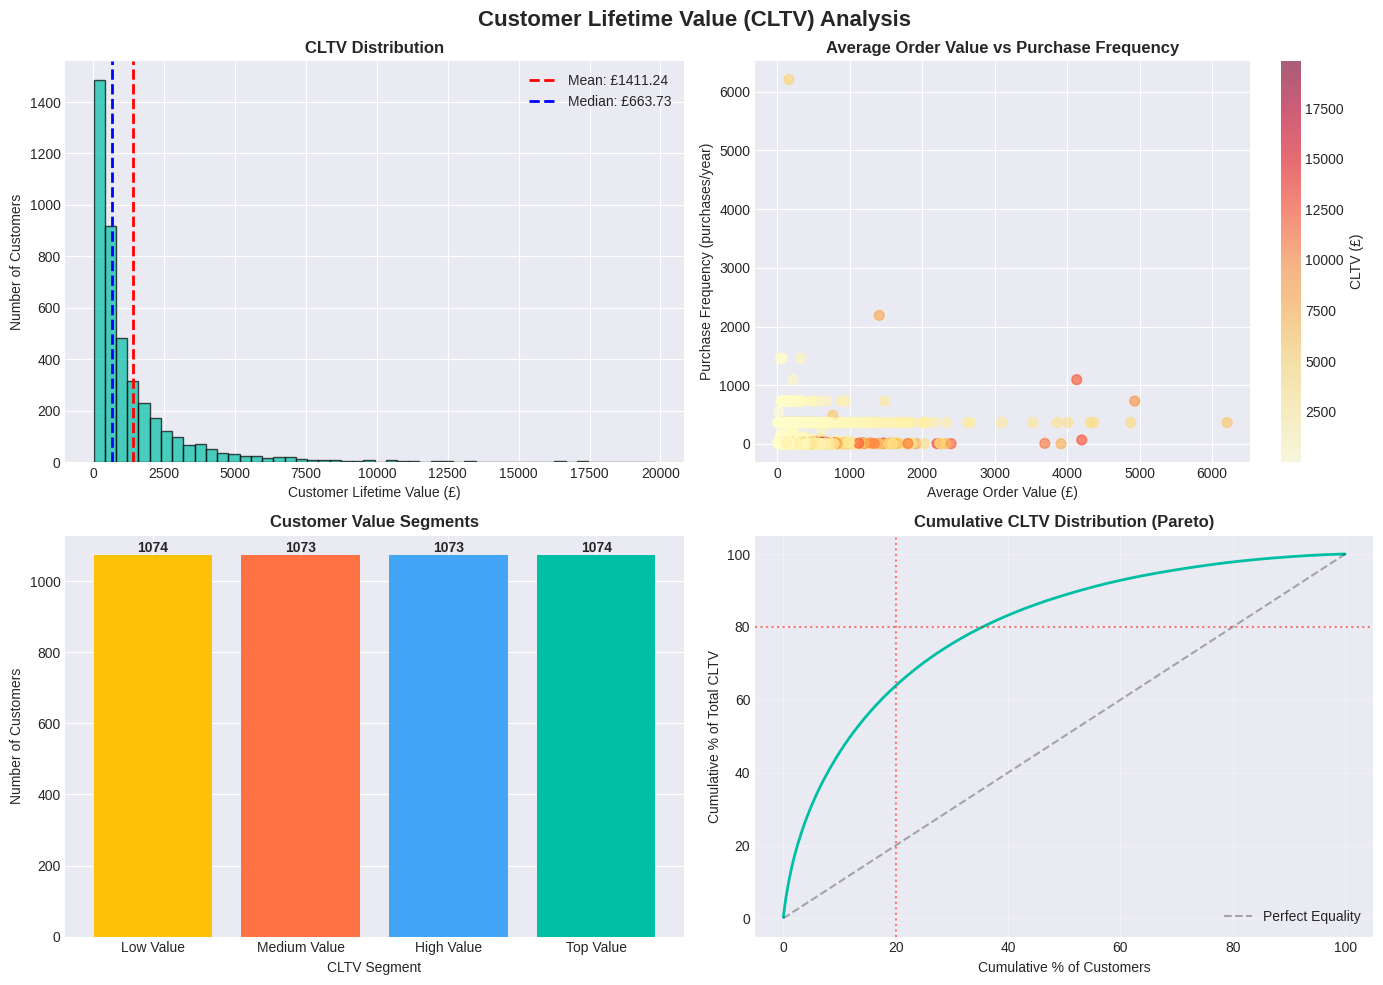

CLTV visualization complete!


In [ ]:
# ============================================================================
# STEP 7: VISUALIZE CLTV
# ============================================================================
print("\n[STEP 7] Creating CLTV visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Lifetime Value (CLTV) Analysis', fontsize=16, fontweight='bold')

# CLTV Distribution
axes[0, 0].hist(cltv_data_clean['CLTV'], bins=50, color='#00BFA5', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('CLTV Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Customer Lifetime Value (£)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].axvline(cltv_data_clean['CLTV'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: £{cltv_data_clean["CLTV"].mean():.2f}')
axes[0, 0].axvline(cltv_data_clean['CLTV'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: £{cltv_data_clean["CLTV"].median():.2f}')
axes[0, 0].legend()

# Average Order Value vs Purchase Frequency
scatter = axes[0, 1].scatter(cltv_data_clean['AvgOrderValue'], cltv_data_clean['PurchaseFrequency'],
                             c=cltv_data_clean['CLTV'], cmap='YlOrRd', alpha=0.6, s=50)
axes[0, 1].set_title('Average Order Value vs Purchase Frequency', fontweight='bold')
axes[0, 1].set_xlabel('Average Order Value (£)')
axes[0, 1].set_ylabel('Purchase Frequency (purchases/year)')
plt.colorbar(scatter, ax=axes[0, 1], label='CLTV (£)')

# CLTV Segments
cltv_quartiles = pd.qcut(cltv_data_clean['CLTV'], q=4, labels=['Low Value', 'Medium Value', 'High Value', 'Top Value'])
segment_counts = cltv_quartiles.value_counts().sort_index()
colors = ['#FFC107', '#FF7043', '#42A5F5', '#00BFA5']
axes[1, 0].bar(segment_counts.index, segment_counts.values, color=colors)
axes[1, 0].set_title('Customer Value Segments', fontweight='bold')
axes[1, 0].set_xlabel('CLTV Segment')
axes[1, 0].set_ylabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    axes[1, 0].text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')

# Cumulative CLTV (Pareto Chart)
sorted_cltv = cltv_data_clean.sort_values('CLTV', ascending=False)
sorted_cltv['CumulativePercent'] = (sorted_cltv['CLTV'].cumsum() / sorted_cltv['CLTV'].sum()) * 100
sorted_cltv['CustomerPercent'] = (np.arange(1, len(sorted_cltv) + 1) / len(sorted_cltv)) * 100

axes[1, 1].plot(sorted_cltv['CustomerPercent'], sorted_cltv['CumulativePercent'], color='#00BFA5', linewidth=2)
axes[1, 1].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect Equality')
axes[1, 1].set_title('Cumulative CLTV Distribution (Pareto)', fontweight='bold')
axes[1, 1].set_xlabel('Cumulative % of Customers')
axes[1, 1].set_ylabel('Cumulative % of Total CLTV')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(20, color='red', linestyle=':', alpha=0.5)
axes[1, 1].axhline(80, color='red', linestyle=':', alpha=0.5)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("CLTV visualization complete!")